In [57]:
import os ## gestion des fichiers et dossiers
import numpy as np # calcul numérique et matrices
import pandas as pd # # manipulation de tableaux (DataFrame)
import geopandas as gpd ## données géographiques (shapefile, cartes)
import matplotlib.pyplot as plt # graphiques et cartes

# PySAL : voisinage, autocorr spatiale, régressions spatiales
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster

from spreg import OLS, ML_Lag, ML_Error   # OLS / SAR (lag) / SEM (error)


/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: Unable to open /home/onyxia/work/Spatial-Econometrics-/Maroc/geo_data/PROVINCES.shp or /home/onyxia/work/Spatial-Econometrics-/Maroc/geo_data/PROVINCES.SHP.
  return ogr_read(


 .dbf chargé : 61 lignes, 45 colonnes
   Colonnes : ['POLY_ID', 'OBJECTID', 'REGION', 'CODE', 'LIBELLE', 'LIBELAR', 'POP94', 'MEN94', 'POP04', 'MEN04', 'POPC', 'POP', 'POP6', 'POP14', 'POP59', 'POP60', 'CELB', 'MARIE', 'FECON', 'ANALPH', 'AMAZ', 'ARAB', 'ARFR', 'PRIM', 'SUP', 'ACTV', 'PUB', 'PRV', 'MNG', 'HS', 'PROP', 'LOC', 'LOG10', 'LOG50', 'EAU', 'ELEC', 'EVAPUB', 'EVASEP', 'TFX', 'GSM', 'POV', 'VUL', 'SEV', 'IDH', 'IDS']
 .shp chargé : 61 polygones

 GeoDataFrame final : 61 lignes, 46 colonnes
   Colonnes finales : ['POLY_ID', 'OBJECTID', 'REGION', 'CODE', 'LIBELLE', 'LIBELAR', 'POP94', 'MEN94', 'POP04', 'MEN04', 'POPC', 'POP', 'POP6', 'POP14', 'POP59', 'POP60', 'CELB', 'MARIE', 'FECON', 'ANALPH', 'AMAZ', 'ARAB', 'ARFR', 'PRIM', 'SUP', 'ACTV', 'PUB', 'PRV', 'MNG', 'HS', 'PROP', 'LOC', 'LOG10', 'LOG50', 'EAU', 'ELEC', 'EVAPUB', 'EVASEP', 'TFX', 'GSM', 'POV', 'VUL', 'SEV', 'IDH', 'IDS', 'geometry']
   CRS : None

APERÇU DES DONNÉES
   POLY_ID  OBJECTID REGION       CODE              

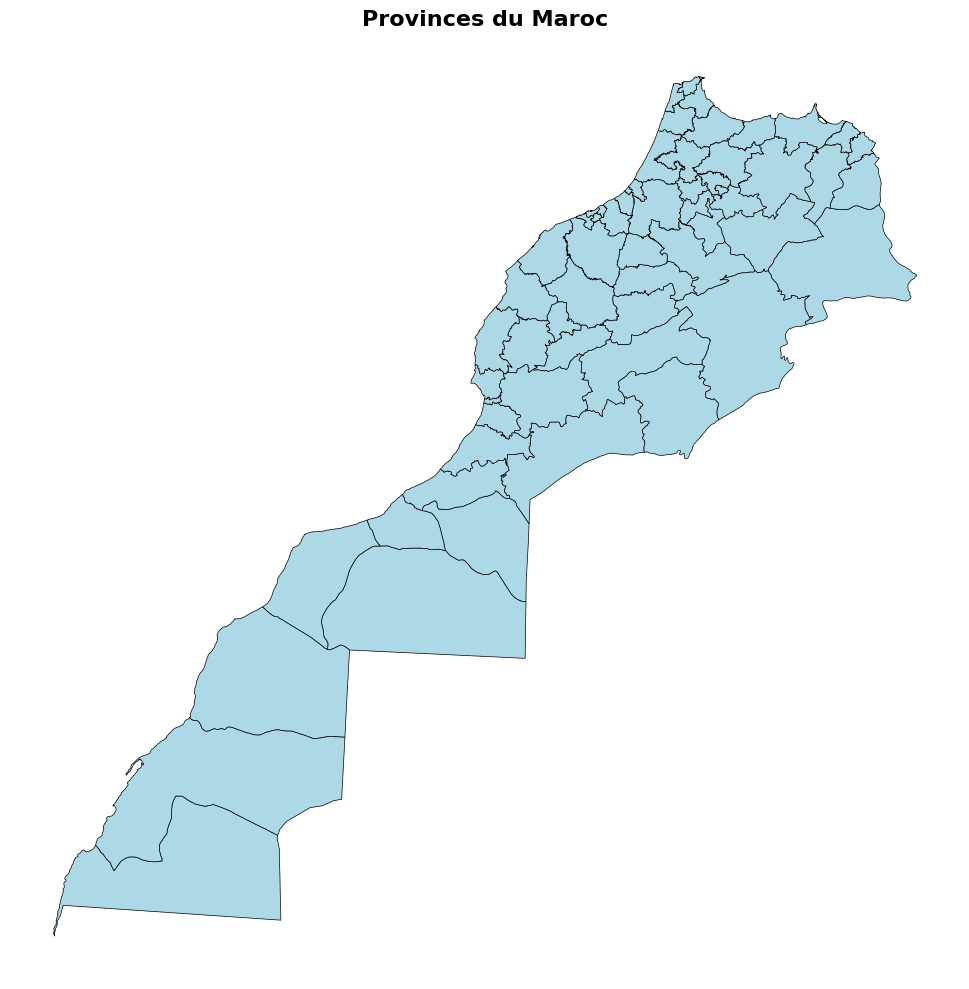


 Données prêtes pour l'analyse spatiale !


In [58]:

# ==========================================
# 1. SETUP : Activer reconstruction .shx
# ==========================================
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

# Chemin de base (adapte selon ton environnement)
folder = "/home/onyxia/work/Spatial-Econometrics-/Maroc/geo_data/"

# ==========================================
# 2. CHARGER LES DEUX FICHIERS SÉPARÉMENT
# ==========================================

# Charger les données attributaires (.dbf)
df_data = gpd.read_file(os.path.join(folder, "PROVINCES.DBF"))
print(f" .dbf chargé : {len(df_data)} lignes, {len(df_data.columns)} colonnes")
print(f"   Colonnes : {df_data.columns.tolist()}")

# Charger les géométries (.shp)
df_geo = gpd.read_file(os.path.join(folder, "provinces.shp"))
print(f" .shp chargé : {len(df_geo)} polygones")

# ==========================================
# 3. CONCAT SIMPLE (méthode directe)
# ==========================================

# Réinitialiser les index pour être sûr
df_data = df_data.reset_index(drop=True)
df_geo = df_geo.reset_index(drop=True)

# Supprimer la colonne geometry du .dbf si elle existe (souvent vide)
if 'geometry' in df_data.columns:
    df_data = df_data.drop(columns=['geometry'])

# CONCAT : combiner horizontalement (axis=1)
gdf = pd.concat([df_data, df_geo[['geometry']]], axis=1)

# Convertir en GeoDataFrame
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=df_geo.crs)

print(f"\n GeoDataFrame final : {len(gdf)} lignes, {len(gdf.columns)} colonnes")
print(f"   Colonnes finales : {gdf.columns.tolist()}")
print(f"   CRS : {gdf.crs}")

# ==========================================
# 4. VÉRIFICATION
# ==========================================

print("\n" + "="*60)
print("APERÇU DES DONNÉES")
print("="*60)
print(gdf.head())

# ==========================================
# 5. CARTE RAPIDE
# ==========================================

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
ax.set_axis_off()
ax.set_title("Provinces du Maroc", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Données prêtes pour l'analyse spatiale !")


# Voisinage par continuité (Queen)

In [59]:
# Queen contiguity : voisins si contact (bord OU coin)
w_queen = Queen.from_dataframe(gdf)

print("nb d'unités :", w_queen.n)
print("nb moyen de voisins :", np.mean(list(w_queen.cardinalities.values())))

# Standardisation des poids
# En PySAL: transform="R" => row-standardized (somme des poids = 1 par ligne)
w_queen.transform = "R"

print("CRS actuel :", gdf.crs)

gdf = gdf.set_crs(epsg=4326, allow_override=True) ## Définit le système de coordonnées (CRS) en WGS84 (EPSG:4326) sans reprojeter les données
#4326 est un code du système EPSG (European Petroleum Survey Group) qui identifie un système de coordonnées géographiques. --> distance sont en métres.


nb d'unités : 61
nb moyen de voisins : 4.557377049180328
CRS actuel : None


/tmp/ipykernel_21723/2768041709.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(gdf)


# knn 

In [60]:

# IMPORTANT : pour les distances, il faut une projection métrique.
# Vous êtes déjà dans un CRS projeté (vos coords sont en ~100k etc).
# Si CRS est None ou en degrés, il faut projeter :
if gdf.crs is None:
    raise ValueError(" CRS manquant. Il faut définir gdf = gdf.set_crs(...)")

# On calcule des centroides
centroids = gdf.geometry.centroid
coords = np.column_stack([centroids.x, centroids.y])

w_knn10 = KNN.from_array(coords, k=4)
w_knn10.transform = "R"

print("✅ nb d'unités :", w_knn10.n)
print("✅ voisins moyens :", np.mean(list(w_knn10.cardinalities.values())))


✅ nb d'unités : 61
✅ voisins moyens : 4.0


/tmp/ipykernel_21723/3826398920.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


In [62]:
# ==========================================
#  CHOIX / VERIF DES VARIABLES POUR LA REGRESSION
# ==========================================

# On définit un petit dictionnaire de correspondance des variables.
# On définit un petit dictionnaire de correspondance des variables.
var_y = "POV"
var_x1 = "ANALPH"
var_x2 = "ACTV"

# S'assurer que ce sont bien des numériques (parfois importées en texte)
gdf[var_y]  = pd.to_numeric(gdf[var_y], errors="coerce")
gdf[var_x1] = pd.to_numeric(gdf[var_x1], errors="coerce")
gdf[var_x2] = pd.to_numeric(gdf[var_x2], errors="coerce")

## OLS

In [ ]:


# y doit être (n,1)
y = gdf[[var_y]].values

# X doit être (n,k) ; on ajoute une constante (intercept)
X = gdf[[var_x1, var_x2]].values
X = np.hstack([np.ones((X.shape[0], 1)), X])  # colonne de 1

# Noms (utile pour summary)
name_y = var_y
name_x = ["const", var_x1, var_x2]

ols = OLS(y, X, name_y=name_y, name_x=name_x)

print(ols.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :         POV                Number of Observations:          61
Mean dependent var  :     15.3213                Number of Variables   :           3
S.D. dependent var  :      7.8305                Degrees of Freedom    :          58
R-squared           :      0.6688
Adjusted R-squared  :      0.6574
Sum squared residual:     1218.31                F-statistic           :     58.5726
Sigma-square        :      21.005                Prob(F-statistic)     :   1.205e-14
S.E. of regression  :       4.583                Log likelihood        :    -177.883
Sigma-square ML     :      19.972                Akaike info criterion :     361.766
S.E of regression ML:      4.4690                Schwarz criterion     :     368.098

------------------------------------------------------------

# Interpretation : Les deux coefficients sont significatifs au seuil de 5% . 

- ANALPH : Lorsque le taux d'analphabetisation augmente d'une unité de % en moyenne celà a tendance a augmenter le niveau de pauvreté toute chose égale par ailleur. 
- ACTV : Lorsque le taux d'actif augmente d'une unité de % cela fait baisser de 76 % en moyenne le taux de pauvreté. 


## TESTS LM (SAR vs SEM)

In [65]:

from spreg import diagnostics_sp

lm_tests_queen = diagnostics_sp.LMtests(ols, w_queen, tests=["LMlag", "LMerror", "RLMlag", "RLMerror", "SARMA"])
print("=== LM tests (Queen contiguity) ===")
print(lm_tests_queen)

=== LM tests (Queen contiguity) ===


## Résultats indi

In [77]:
# ==========================================
# SAR (Spatial Lag) - ML
# ==========================================

sar_queen = ML_Lag(y, X, w=w_queen, name_y=name_y, name_x=name_x)
print(sar_queen.summary)

sar_knn = ML_Lag(y, X, w=w_knn10, name_y=name_y, name_x=name_x)
print(sar_knn.summary)

# ==========================================
#  SEM (Spatial Error) - ML
# ==========================================

sem_queen = ML_Error(y, X, w=w_queen, name_y=name_y, name_x=name_x)
print(sem_queen.summary)

sem_knn = ML_Error(y, X, w=w_knn10, name_y=name_y, name_x=name_x)
print(sem_knn.summary)

!pip install --upgrade spreg libpysal

#SDM
sdm = ML_Lag(
    y, X,
    w=w_queen,
    slx_lags=1,   # ajoute WX
    name_y=name_y,
    name_x=name_x
)
print(sdm.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :         POV                Number of Observations:          61
Mean dependent var  :     15.3213                Number of Variables   :           4
S.D. dependent var  :      7.8305                Degrees of Freedom    :          57
Pseudo R-squared    :      0.7560
Spatial Pseudo R-squared:  0.6873
Log likelihood      :   -170.0805
Sigma-square ML     :     14.7298                Akaike info criterion :     348.161
S.E of regression   :      3.8379                Schwarz criterion     :     356.605

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

/opt/python/lib/python3.13/site-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
/opt/python/lib/python3.13/site-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
-------------------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :         POV                Number of Observations:          61
Mean dependent var  :     15.3213                Number of Variables   :           6
S.D. dependent var  :      7.8305                Degrees of Freedom    :          55
Pseudo R-squared    :      0.7747
Spatial Pseudo R-squared:  0.6906
Log likelihood      :   -169.0183
Sigma-square ML     :     13.6350                Akaike info criterion :     350.037
S.E of regression   :      3.6926                Schwarz criterion     :     362.702

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability

# Interprétation des modèles spatiaux

## Modèle SAR (Spatial AutoRegressive)

Le coefficient spatial **ρ = 0.427*** (p < 0.001) est positif et statistiquement significatif, indiquant que **le niveau de pauvreté d'une province est positivement influencé par le niveau de pauvreté moyen de ses provinces voisines**.

Si les provinces voisines présentent un taux de pauvreté élevé, la province considérée aura tendance à avoir un taux de pauvreté plus élevé également, toutes choses égales par ailleurs. Ce résultat met en évidence un **effet de diffusion spatiale** ou de **contagion de la pauvreté** entre provinces voisines au Maroc.

**Implication :** Cette dépendance spatiale suggère que les politiques de lutte contre la pauvreté doivent prendre en compte les effets de débordement géographiques. Réduire la pauvreté dans une province peut générer des effets positifs sur les provinces voisines, justifiant une approche territoriale coordonnée.

---

## Modèle SEM (Spatial Error Model)

Le coefficient d'autocorrélation spatiale des erreurs **λ = 0.622*** (p < 0.001) est positif et statistiquement significatif. Cela indique que **les erreurs du modèle sont spatialement corrélées** : les chocs non observés (variables omises) qui affectent une province ont tendance à également affecter les provinces voisines.

Il existe des facteurs non mesurés dans le modèle (politiques régionales, chocs climatiques, dynamiques culturelles, etc.) qui présentent une **structure spatiale**. Lorsqu'ils influencent une province, ils influencent également ses voisines de manière similaire.

**Implication :** Ce résultat suggère que la pauvreté est influencée par des phénomènes régionaux diffus non capturés par les variables explicatives (ANALPHA et ACTIV). Ces phénomènes se diffusent géographiquement et révèlent la nécessité d'enrichir le modèle avec des variables spatiales supplémentaires.

---

## Décomposition des effets spatiaux

La décomposition des effets directs, indirects et totaux des variables explicatives sur le taux de pauvreté, proposée par **LeSage et Pace (2009)**, permet de distinguer :
- **Effet direct** : Impact local d'une variable sur sa propre province
- **Effet indirect** : Effet de débordement (*spillover*) sur les provinces voisines
- **Effet total** : Somme des effets direct et indirect

### Analphabétisme (ANALPH)

| Effet | Coefficient | Interprétation |
|-------|-------------|----------------|
| **Direct** | 0.3792*** | Une augmentation de 1 point du taux d'analphabétisme augmente le taux de pauvreté local de **0.38 points** |
| **Indirect** | 0.1748*** | Effet de débordement sur les provinces voisines : **+0.17 points** |
| **Total** | 0.5540*** | Impact global sur l'ensemble du système spatial : **+0.55 points** (68% direct, 32% indirect) |

**Interprétation :** L'analphabétisme limite les opportunités d'emploi localement et génère des **externalités spatiales négatives**. Il freine le développement économique régional et réduit les opportunités dans les provinces limitrophes, notamment via la mobilité de la main-d'œuvre peu qualifiée.

### Activité économique (ACTV)

| Effet | Coefficient | Interprétation |
|-------|-------------|----------------|
| **Direct** | -0.5997*** | Une augmentation de 1 point du taux d'activité réduit le taux de pauvreté local de **0.60 points** |
| **Indirect** | -0.2550*** | Effet de débordement sur les provinces voisines : **-0.26 points** |
| **Total** | -0.8547*** | Impact global sur l'ensemble du système spatial : **-0.85 points** (70% direct, 30% indirect) |

**Interprétation :** L'emploi constitue le principal levier de sortie de la pauvreté. Une province économiquement dynamique génère des **externalités spatiales positives** en stimulant l'activité régionale (commerce interrégional, mobilité de la main-d'œuvre, investissements), amplifiant l'effet de réduction de la pauvreté de **42%**.

---

## Implications pour les politiques publiques

Ces résultats soulignent l'importance des **politiques territoriales coordonnées** :

1. **Amplification des impacts** : Investir dans l'éducation ou stimuler l'emploi dans une province génère non seulement des bénéfices locaux mais aussi des retombées positives pour les provinces voisines (30-32% de l'effet total).

2. **Sous-estimation des effets** : Ignorer ces interdépendances spatiales conduit à sous-estimer l'impact réel des politiques publiques de **42 à 46%**.

3. **Approche régionale** : Les politiques de lutte contre la pauvreté doivent adopter une **dimension territoriale** plutôt que de traiter chaque province isolément, en tenant compte des effets de débordement géographiques.

4. **Ciblage stratégique** : Réduire la pauvreté dans une province génère des effets multiplicateurs positifs sur l'ensemble de sa région, justifiant un ciblage stratégique des investissements publics.


## Indice  MORAN GLOBAL + SCATTERPLOT

Moran I = 0.5224371706442457
p-value (permutation) = 0.001


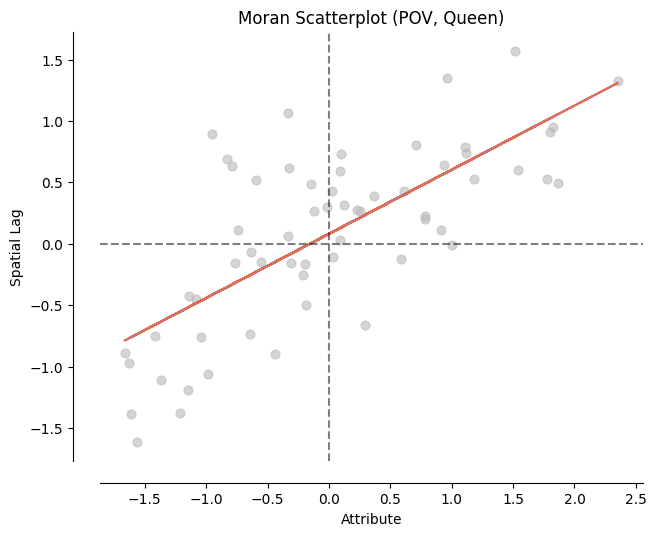

In [71]:
# Moran global sur POV
mi = Moran(gdf[var_y].values, w_queen)
print("Moran I =", mi.I)
print("p-value (permutation) =", mi.p_sim)

# Scatterplot Moran
fig, ax = moran_scatterplot(mi)
ax.set_title("Moran Scatterplot (POV, Queen)")
plt.show()

import numpy as np
import pandas as pd
from esda.moran import Moran_Local

# -----------------------------
# 0) Choisir la variable et la matrice de poids
# -----------------------------
var_y = "POV"       # variable d'intérêt
w = w_queen         # ou w_knn10 (selon ce que vous voulez)

# Optionnel mais recommandé : standardisation des poids (comme style="W" dans R)
w.transform = "R"   # "R" = row-standardized

# -----------------------------
# 1) Extraire y (attention aux NaN)
# -----------------------------
y = gdf[var_y].astype(float).values
mask = np.isfinite(y)

# IMPORTANT : si NaN, il faut filtrer à la fois gdf et w (sinon erreur)
if mask.sum() != len(y):
    gdf_lisa = gdf.loc[mask].copy()
    y = gdf_lisa[var_y].astype(float).values
    w = w.subset(gdf_lisa.index.tolist())
else:
    gdf_lisa = gdf.copy()


# Interpretation :  

I de Moran = 0,5224 indique une autocorrélation spatiale positive modérée à forte, ce qui signifie que les observations voisines tendent à avoir des valeurs d'attributs similaires. La p-value = 0,001 est hautement significative statistiquement, vous permettant de rejeter l'hypothèse nulle d'aléatoire spatiale à tout seuil de signification conventionnel (α = 0,01, 0,05 ou 0,10)

## Morand local

              Ii       E.Ii     Var.Ii       Z.Ii  Pr(z != E(Ii))
count  61.000000  61.000000  61.000000  61.000000       61.000000
mean    0.513873  -0.013673   0.262410   0.868746        0.165705
std     0.799749   0.021932   0.399014   1.267391        0.151793
min    -0.841627  -0.084753   0.000076  -1.934085        0.001000
25%     0.002347  -0.017140   0.016880   0.071388        0.031000
50%     0.142527  -0.009113   0.104339   0.951055        0.109000
75%     0.914023  -0.000258   0.284688   1.766833        0.285000
max     3.064124   0.025374   2.111384   3.630504        0.489000


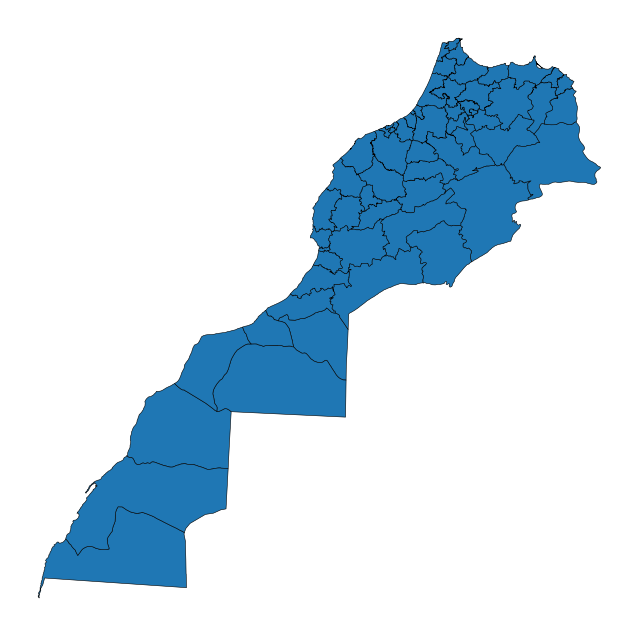

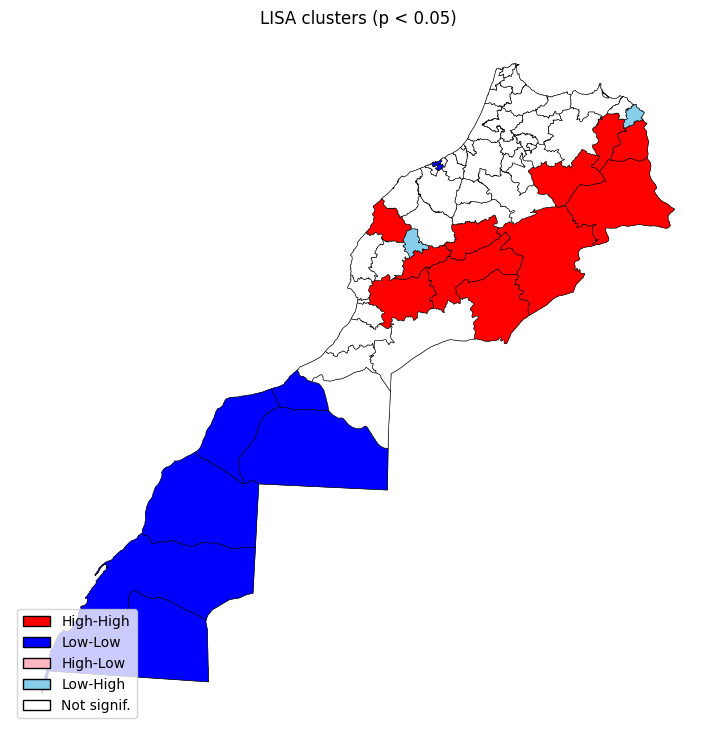

In [ ]:
# permutations=999 comme souvent en pratique (p-values par permutation)
lisa = Moran_Local(y, w, permutations=999) ## pour faire l'inférence statistique


# -----------------------------
# 3) Construire une table type "locm" comme dans R
# -----------------------------
# Moran_Local fournit:
# lisa.Is        : Ii
# lisa.z_sim     : z (simulation/permutation)
# lisa.p_sim     : p-value (permutation)
# lisa.EI_sim    : E(Ii) simulé (si dispo selon version)
# lisa.VI_sim    : Var(Ii) simulé (si dispo selon version)

locm = pd.DataFrame({
    "Ii": lisa.Is,
    "E.Ii": getattr(lisa, "EI_sim", np.full_like(lisa.Is, np.nan, dtype=float)),
    "Var.Ii": getattr(lisa, "VI_sim", np.full_like(lisa.Is, np.nan, dtype=float)),
    "Z.Ii": lisa.z_sim,
    "Pr(z != E(Ii))": lisa.p_sim
}, index=gdf_lisa.index)

# Ajouter au GeoDataFrame
gdf_lisa["Ii"] = locm["Ii"]
gdf_lisa["Z.Ii"] = locm["Z.Ii"]
gdf_lisa["pvalue"] = locm["Pr(z != E(Ii))"]
gdf_lisa["quadrant"] = lisa.q  # 1 HH, 2 LH, 3 LL, 4 HL

# -----------------------------
# 4) "summary(locm)" version Python
# -----------------------------
print(locm.describe())

# Correction de la  projection si nécessaire
gdf_lisa = gdf_lisa.set_crs(epsg=3857, allow_override=True)

# test plot

fig, ax = plt.subplots(figsize=(8,8))
gdf_lisa.plot(ax=ax, edgecolor="black", linewidth=0.4)
ax.set_axis_off()
plt.show()

alpha = 0.05

# clusters lisibles (en gardant la convention de quadrant)
gdf_lisa["cluster"] = "Not signif."
sig = gdf_lisa["pvalue"] <= alpha

gdf_lisa.loc[sig & (gdf_lisa["quadrant"] == 1), "cluster"] = "High-High"
gdf_lisa.loc[sig & (gdf_lisa["quadrant"] == 2), "cluster"] = "Low-High"
gdf_lisa.loc[sig & (gdf_lisa["quadrant"] == 3), "cluster"] = "Low-Low"
gdf_lisa.loc[sig & (gdf_lisa["quadrant"] == 4), "cluster"] = "High-Low"

palette = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "lightpink",
    "Low-High": "skyblue",
    "Not signif.": "white",
}
order = ["High-High", "Low-Low", "High-Low", "Low-High", "Not signif."]

fig, ax = plt.subplots(figsize=(9,9))

# fond
gdf_lisa.plot(ax=ax, color="white", edgecolor="black", linewidth=0.4)

# couches
for cat in order:
    sel = gdf_lisa["cluster"] == cat
    if sel.sum() == 0:
        continue
    gdf_lisa.loc[sel].plot(ax=ax, color=palette[cat], edgecolor="black", linewidth=0.4)

ax.set_title(f"LISA clusters (p < {alpha})")
ax.axis("off")
handles = [Patch(facecolor=palette[c], edgecolor="black", label=c) for c in order]
ax.legend(handles=handles, loc="lower left", frameon=True)

plt.show()



